In [5]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()
from langgraph.checkpoint.memory import InMemorySaver


In [6]:
llm = ChatGroq(model = "llama-3.3-70b-versatile")
llm1 = ChatGroq(model = "openai/gpt-oss-120b")

In [7]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

def create_joke(state: JokeState):

    prompt = f"generate a joke on the topic: {state['topic']}"
    response = llm.invoke(prompt).content
    return {'joke': response}

def explain_joke(state: JokeState):

    prompt = f"explain this joke: {state['joke']}"
    response = llm1.invoke(prompt).content
    return {'explanation':response}



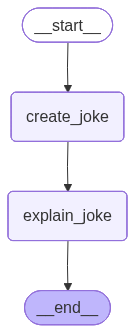

In [8]:
from langgraph.checkpoint.memory import InMemorySaver
graph = StateGraph(JokeState)

graph.add_node("create_joke",create_joke)
graph.add_node("explain_joke",explain_joke)

graph.add_edge(START,"create_joke")
graph.add_edge("create_joke","explain_joke")
graph.add_edge("explain_joke",END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

workflow

In [9]:
config1 = {"configurable":{"thread_id":"1"}}
final_state = workflow.invoke({'topic':'pizza'},config = config1)

In [14]:
print(final_state)

{'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood. \n\nBecause it was feeling a little crusty.', 'explanation': '**The joke**\n\n> **Q:** Why was the pizza in a bad mood?  \n> **A:** Because it was feeling a little *crusty*.\n\n---\n\n### Why it’s funny\n\n1. **Wordplay (a pun)**\n   - **Crust** is the outer, baked edge of a pizza.  \n   - **“Crusty”** is also an informal adjective meaning “irritable, grumpy, or in a bad mood” (e.g., “He woke up feeling crusty”).  \n   - The punchline swaps the literal meaning (the pizza’s crust) for the figurative, human‑like meaning of “crusty.” The double‑meaning catches the listener off guard.\n\n2. **Anthropomorphism**\n   - The joke treats the pizza as if it were a person capable of emotions. That absurd mental image—“a pizza being moody”—adds a whimsical, light‑hearted touch.\n\n3. **Setup–punchline structure**\n   - **Setup:** “Why was the pizza in a bad mood?” invites you to think of a reason related to emotions, perhaps something ab

In [15]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood. \n\nBecause it was feeling a little crusty.', 'explanation': '**The joke**\n\n> **Q:** Why was the pizza in a bad mood?  \n> **A:** Because it was feeling a little *crusty*.\n\n---\n\n### Why it’s funny\n\n1. **Wordplay (a pun)**\n   - **Crust** is the outer, baked edge of a pizza.  \n   - **“Crusty”** is also an informal adjective meaning “irritable, grumpy, or in a bad mood” (e.g., “He woke up feeling crusty”).  \n   - The punchline swaps the literal meaning (the pizza’s crust) for the figurative, human‑like meaning of “crusty.” The double‑meaning catches the listener off guard.\n\n2. **Anthropomorphism**\n   - The joke treats the pizza as if it were a person capable of emotions. That absurd mental image—“a pizza being moody”—adds a whimsical, light‑hearted touch.\n\n3. **Setup–punchline structure**\n   - **Setup:** “Why was the pizza in a bad mood?” invites you to think of a reason related to emotions,

In [16]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood. \n\nBecause it was feeling a little crusty.', 'explanation': '**The joke**\n\n> **Q:** Why was the pizza in a bad mood?  \n> **A:** Because it was feeling a little *crusty*.\n\n---\n\n### Why it’s funny\n\n1. **Wordplay (a pun)**\n   - **Crust** is the outer, baked edge of a pizza.  \n   - **“Crusty”** is also an informal adjective meaning “irritable, grumpy, or in a bad mood” (e.g., “He woke up feeling crusty”).  \n   - The punchline swaps the literal meaning (the pizza’s crust) for the figurative, human‑like meaning of “crusty.” The double‑meaning catches the listener off guard.\n\n2. **Anthropomorphism**\n   - The joke treats the pizza as if it were a person capable of emotions. That absurd mental image—“a pizza being moody”—adds a whimsical, light‑hearted touch.\n\n3. **Setup–punchline structure**\n   - **Setup:** “Why was the pizza in a bad mood?” invites you to think of a reason related to emotions

In [18]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f138123-9237-6557-8002-4bcfa0d3337e"}})

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood. \n\nBecause it was feeling a little crusty.', 'explanation': '**The joke**\n\n> **Q:** Why was the pizza in a bad mood?  \n> **A:** Because it was feeling a little *crusty*.\n\n---\n\n### Why it’s funny\n\n1. **Wordplay (a pun)**\n   - **Crust** is the outer, baked edge of a pizza.  \n   - **“Crusty”** is also an informal adjective meaning “irritable, grumpy, or in a bad mood” (e.g., “He woke up feeling crusty”).  \n   - The punchline swaps the literal meaning (the pizza’s crust) for the figurative, human‑like meaning of “crusty.” The double‑meaning catches the listener off guard.\n\n2. **Anthropomorphism**\n   - The joke treats the pizza as if it were a person capable of emotions. That absurd mental image—“a pizza being moody”—adds a whimsical, light‑hearted touch.\n\n3. **Setup–punchline structure**\n   - **Setup:** “Why was the pizza in a bad mood?” invites you to think of a reason related to emotions,

In [3]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [4]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3:str

In [5]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(1000)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

In [6]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [ ]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config= {"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)


In [1]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state) 


🔁 Re-running the graph to demonstrate fault tolerance...


NameError: name 'graph' is not defined